# Online Retails Purchase

### Introduction:



### Step 1. Import the necessary libraries

In [2]:
import pandas as pd 
import numpy as np

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/07_Visualization/Online_Retail/Online_Retail.csv). 

In [3]:
online_rt=pd.read_csv('https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/07_Visualization/Online_Retail/Online_Retail.csv',sep=',',encoding='latin1')

### Step 3. Assign it to a variable called online_rt
Note: if you receive a utf-8 decode error, set `encoding = 'latin1'` in `pd.read_csv()`.

In [4]:
online_rt

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/11 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/11 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/11 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/11 12:50,4.15,12680.0,France


In [5]:
#CustomerID and InvoiceNo:Foreign Key
#StockCode:Primary Key

### Step 4. Create a histogram with the 10 countries that have the most 'Quantity' ordered except UK

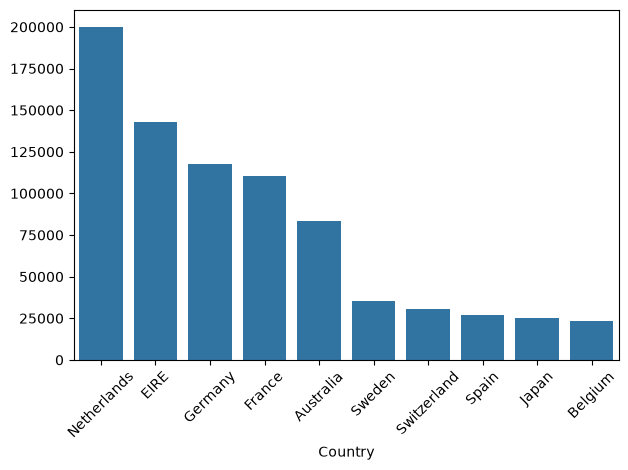

In [6]:
grouped=online_rt.groupby(['Country'])['Quantity'].sum().sort_values(ascending=False)[1:11]
# grouped

#creating barplot
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(x=grouped.index,y=grouped.values)

plt.xticks(rotation=45)
plt.tight_layout()


### Step 5.  Exclude negative Quantity entries

In [7]:
#defining filter
filter_=online_rt.Quantity<0
# online_rt[filter_].index
online_rt.drop(index=online_rt[filter_].index,inplace=True)
online_rt.reset_index(drop=True)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
531280,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/11 12:50,0.85,12680.0,France
531281,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/11 12:50,2.10,12680.0,France
531282,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/11 12:50,4.15,12680.0,France
531283,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/11 12:50,4.15,12680.0,France


### Step 6. Create a scatterplot with the Quantity per UnitPrice by CustomerID for the top 3 Countries (except UK)

0      26185.72
1      12949.99
2       9070.93
3       5357.68
4       5176.09
         ...   
421        7.16
422        4.99
423        4.74
424        2.97
425        1.06
Name: UnitPrice, Length: 426, dtype: float64


<Axes: xlabel='Quantity', ylabel='UnitPrice'>

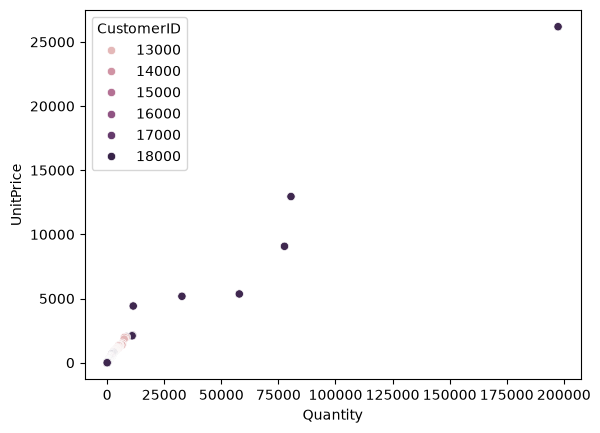

In [8]:
# grouped1=online_rt.groupby(['UnitPrice'])['Quantity'].sum()
# grouped1

#defining filter
filter_=online_rt['Country']!='United Kingdom'
# online_rt[filter_]


customers=online_rt[filter_].groupby(['CustomerID','Country']).sum()



# customers['Country']=customers.index.get_level_values(0)
# customers

totalQuantity=customers['Quantity'].sort_values(ascending=False).reset_index(drop=True)
# print(totalQuantity)


totalUnitPrice=customers['UnitPrice'].sort_values(ascending=False).reset_index(drop=True)
print(totalUnitPrice)


#importing required libraries
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x=totalQuantity,y=totalUnitPrice,hue=online_rt.CustomerID)


### Step 7. Investigate why the previous results look so uninformative.

This section might seem a bit tedious to go through. But I've thought of it as some kind of a simulation of problems one might encounter when dealing with data and other people. Besides there is a prize at the end (i.e. Section 8).

(But feel free to jump right ahead into Section 8 if you want; it doesn't require that you finish this section.)

#### Step 7.1 Look at the first line of code in Step 6. And try to figure out if it leads to any kind of problem.
##### Step 7.1.1 Display the first few rows of that DataFrame.

In [9]:
online_rt.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


##### Step 7.1.2 Think about what that piece of code does and display the dtype of `UnitPrice`

In [10]:
online_rt.UnitPrice.dtype

"""
So it's 'float64' 
But why did we sum 'UnitPrice',to begin with/
If 'UnitPrice' wasn't something that we are interested in then it would be OK
since we wouldn't care whether UnitPrice was being summed or not.
But we want our graphs to reflect 'UnitPrice'!
Not that summing up 'UnitPrice' can be highly misleading
It doesn't tell us much as to what the customer is doing.
Suppose,a customer places one order of 1000 items that are worth $1 each.
Anohter customer places a thousand orders of 1 item worth $1.
There isn't much of a difference between what the former and the latter customers did.
After all,they've spent the same amount of money.
so we should be careful when we're summing columns,Sometimes we intend to sum just one column
('Quantitiy' in this case)  and another column like UnitPrice gets into the mix.

"""

"\nSo it's 'float64' \nBut why did we sum 'UnitPrice',to begin with/\nIf 'UnitPrice' wasn't something that we are interested in then it would be OK\nsince we wouldn't care whether UnitPrice was being summed or not.\nBut we want our graphs to reflect 'UnitPrice'!\nNot that summing up 'UnitPrice' can be highly misleading\nIt doesn't tell us much as to what the customer is doing.\nSuppose,a customer places one order of 1000 items that are worth $1 each.\nAnohter customer places a thousand orders of 1 item worth $1.\nThere isn't much of a difference between what the former and the latter customers did.\nAfter all,they've spent the same amount of money.\nso we should be careful when we're summing columns,Sometimes we intend to sum just one column\n('Quantitiy' in this case)  and another column like UnitPrice gets into the mix.\n\n"

##### Step 7.1.3 Pull data from `online_rt`for `CustomerID`s 12346.0 and 12347.0.

In [11]:
# online_rt[((online_rt.CustomerID==12346) |(online_rt.CustomerID==12347))]
display(
    online_rt[online_rt.CustomerID==12347.0].sort_values(
        by='UnitPrice',ascending=False
    ).head()
)
print()
display(online_rt[
    online_rt.CustomerID==12346.0
].sort_values(by='UnitPrice',ascending=False).head())


""" 
The result is exactly what we'd suspected.Customer 12346.0 placed
one giant order,whereas 12347.0 placed a lot of smaller orders.So
we've identified one potential reason why our plots looked so weird at section 6.
"""

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
72267,542237,22423,REGENCY CAKESTAND 3 TIER,3,1/26/11 14:30,12.75,12347.0,Iceland
148300,549222,22423,REGENCY CAKESTAND 3 TIER,3,4/7/11 10:43,12.75,12347.0,Iceland
286637,562032,22423,REGENCY CAKESTAND 3 TIER,3,8/2/11 8:48,12.75,12347.0,Iceland
428966,573511,22423,REGENCY CAKESTAND 3 TIER,6,10/31/11 12:25,12.75,12347.0,Iceland
220577,556201,23173,REGENCY TEAPOT ROSES,2,6/9/11 13:01,9.95,12347.0,Iceland


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1/18/11 10:01,1.04,12346.0,United Kingdom


" \nThe result is exactly what we'd suspected.Customer 12346.0 placed\none giant order,whereas 12347.0 placed a lot of smaller orders.So\nwe've identified one potential reason why our plots looked so weird at section 6.\n"

#### Step 7.2 Reinterpreting the initial problem.

To reiterate the question that we were dealing with:  
"Create a scatterplot with the Quantity per UnitPrice by CustomerID for the top 3 Countries"

The question is open to a set of different interpretations.
We need to disambiguate.

We could do a single plot by looking at all the data from the top 3 countries.
Or we could do one plot per country. To keep things consistent with the rest of the exercise,
let's stick to the latter oprion. So that's settled.

But "top 3 countries" with respect to what? Two answers suggest themselves:
Total sales volume (i.e. total quantity sold) or total sales (i.e. revenue).
This exercise goes for sales volume, so let's stick to that.

##### Step 7.2.1 Find out the top 3 countries in terms of sales volume.

In [12]:
sales_volume=online_rt.groupby('Country').Quantity.sum().sort_values(ascending=False)

top3=sales_volume.index[1:4] #we are excluding UK
top3

Index(['Netherlands', 'EIRE', 'Germany'], dtype='str', name='Country')

##### Step 7.2.2 

Now that we have the top 3 countries, we can focus on the rest of the problem:  
"Quantity per UnitPrice by CustomerID".  
We need to unpack that.

"by CustomerID" part is easy. That means we're going to be plotting one dot per CustomerID's on our plot. In other words, we're going to be grouping by CustomerID.

"Quantity per UnitPrice" is trickier. Here's what we know:  
*One axis will represent a Quantity assigned to a given customer. This is easy; we can just plot the total  Quantity for each customer.  
*The other axis will represent a UnitPrice assigned to a given customer. Remember a single customer can have any number of orders with different prices, so summing up prices isn't quite helpful. Besides it's not quite clear what we mean when we say "unit price per customer"; it sounds like price of the customer! A reasonable alternative is that we assign each customer the average amount each has paid per item. So let's settle that question in that manner.

#### Step 7.3 Modify, select and plot data
##### Step 7.3.1 Add a column to online_rt called `Revenue` calculate the revenue (Quantity * UnitPrice) from each sale.
We will use this later to figure out an average price per customer.

In [13]:
online_rt['Revenue']=online_rt.Quantity*online_rt.UnitPrice
online_rt.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom,20.34


##### Step 7.3.2 Group by `CustomerID` and `Country` and find out the average price (`AvgPrice`) each customer spends per unit.

In [14]:
grouped=online_rt[online_rt.Country.isin(top3)].groupby(['CustomerID','Country'])
# grouped

plottable=grouped[['Quantity','Revenue']].agg('sum')
plottable['AvgPrice']=plottable.Revenue/plottable.Quantity

#get the value of the index and put in the column Country
plottable['Country']=plottable.index.get_level_values(1)
plottable.head()

,,Quantity,Revenue,AvgPrice,Country
CustomerID,Country,,,,
12426.0,Germany,258,582.73,2.258643,Germany
12427.0,Germany,533,825.80,1.549343,Germany
12468.0,Germany,366,729.54,1.993279,Germany
12471.0,Germany,8212,19824.05,2.414034,Germany
12472.0,Germany,4148,6572.11,1.584405,Germany


##### Step 7.3.3 Plot

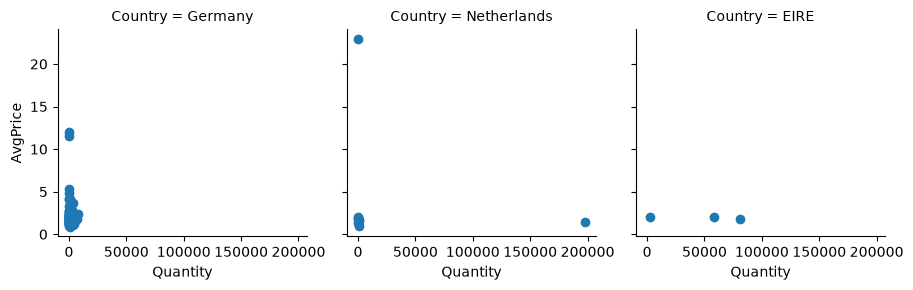

In [15]:
##################
#Graph Section v2 #
###################

#creates the FaceGrid
g=sns.FacetGrid(plottable,col='Country')

#map over a make scatterplot
g.map(plt.scatter,'Quantity','AvgPrice',alpha=1)

#add legend
g.add_legend()


#### Step 7.4 What to do now?
We aren't much better-off than what we started with. The data are still extremely scattered around and don't seem quite informative.

But we shouldn't despair!
There are two things to realize:
1) The data seem to be skewed towaards the axes (e.g. we don't have any values where Quantity = 50000 and AvgPrice = 5). So that might suggest a trend.
2) We have more data! We've only been looking at the data from 3 different countries and they are plotted on different graphs.

So: we should plot the data regardless of `Country` and hopefully see a less scattered graph.

##### Step 7.4.1 Plot the data for each `CustomerID` on a single graph

[]

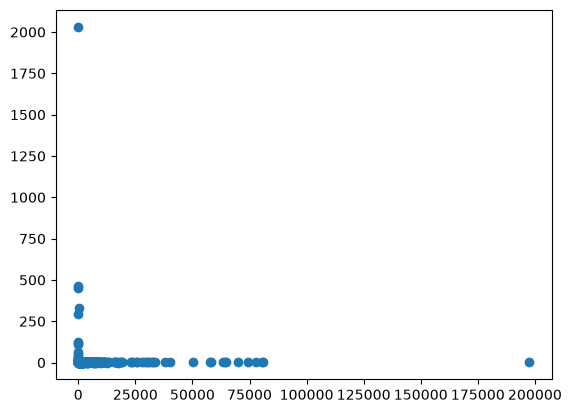

In [16]:
grouped=online_rt.groupby(['CustomerID'])
plottable=grouped[['Quantity','Revenue']].agg('sum')
plottable['AvgPrice']=plottable.Revenue/plottable.Quantity

#map over a make a scatterplot
plt.scatter(plottable.Quantity,plottable.AvgPrice)
plt.plot()

#Turns out the graph is still extremely skewed towards the axes like an exponential decay function

##### Step 7.4.2 Zoom in so we can see that curve more clearly

[]

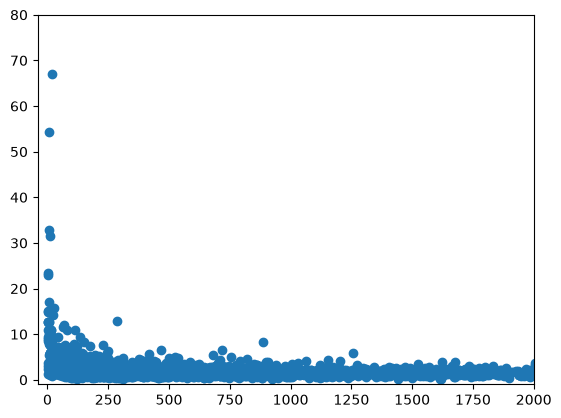

In [17]:
grouped=online_rt.groupby(
    ['CustomerID','Country']
)
plottable['AvgPrice']=plottable.Revenue/plottable.Quantity

#map over a make a scatterplot
plt.scatter(plottable.Quantity,plottable.AvgPrice)

#Zooming in,(I'm starting the axes from a negative so that
#the dots can be plotted in the graph completely.)

plt.xlim(-40,2000)
plt.ylim(-1,80)

plt.plot()

#And there is still that pattern,this time in close-up!

### 8. Plot a line chart showing revenue (y) per UnitPrice (x).

Did Step 7 give us any insights about the data? Sure! As average price increases, the quantity ordered decreses.  But that's hardly surprising. It would be surprising if that wasn't the case!

Nevertheless the rate of drop in quantity is so drastic, it makes me wonder how our revenue changes with respect to item price. It would not be that surprising if it didn't change that much. But it would be interesting to know whether most of our revenue comes from expensive or inexpensive items, and how that relation looks like.

That is what we are going to do now.

#### 8.1 Group `UnitPrice` by intervals of 1 for prices [0,50), and sum `Quantity` and `Revenue`.

In [18]:
# filter_=(online_rt.UnitPrice<50)&(0<=online_rt.UnitPrice)
# grouped=online_rt[filter_].groupby('UnitPrice')
# # grouped.agg(['sum'])[['Quantity','Revenue']]
# plottable=grouped[['Quantity','Revenue']].sum()

In [19]:
###Solution
#These are the values for the graph.
#They are used both in selecting data from
#the DataFrame and plotting the data so I've assigned
#them to variables to increase consistency and make things easier
#when playing with the variables.
price_start=0
price_end=50
price_interval=1

#Creating the buckets to collect the data accordingly
buckets=np.arange(price_start,price_end,price_interval)

#Select the data and sum
revenue_per_price=online_rt.groupby(pd.cut(online_rt.UnitPrice,buckets)).Revenue.sum()
revenue_per_price.head()

UnitPrice
(0, 1]    1107774.544
(1, 2]    2691765.110
(2, 3]    2024143.090
(3, 4]     865101.780
(4, 5]    1219377.050
Name: Revenue, dtype: float64

#### 8.3 Plot.

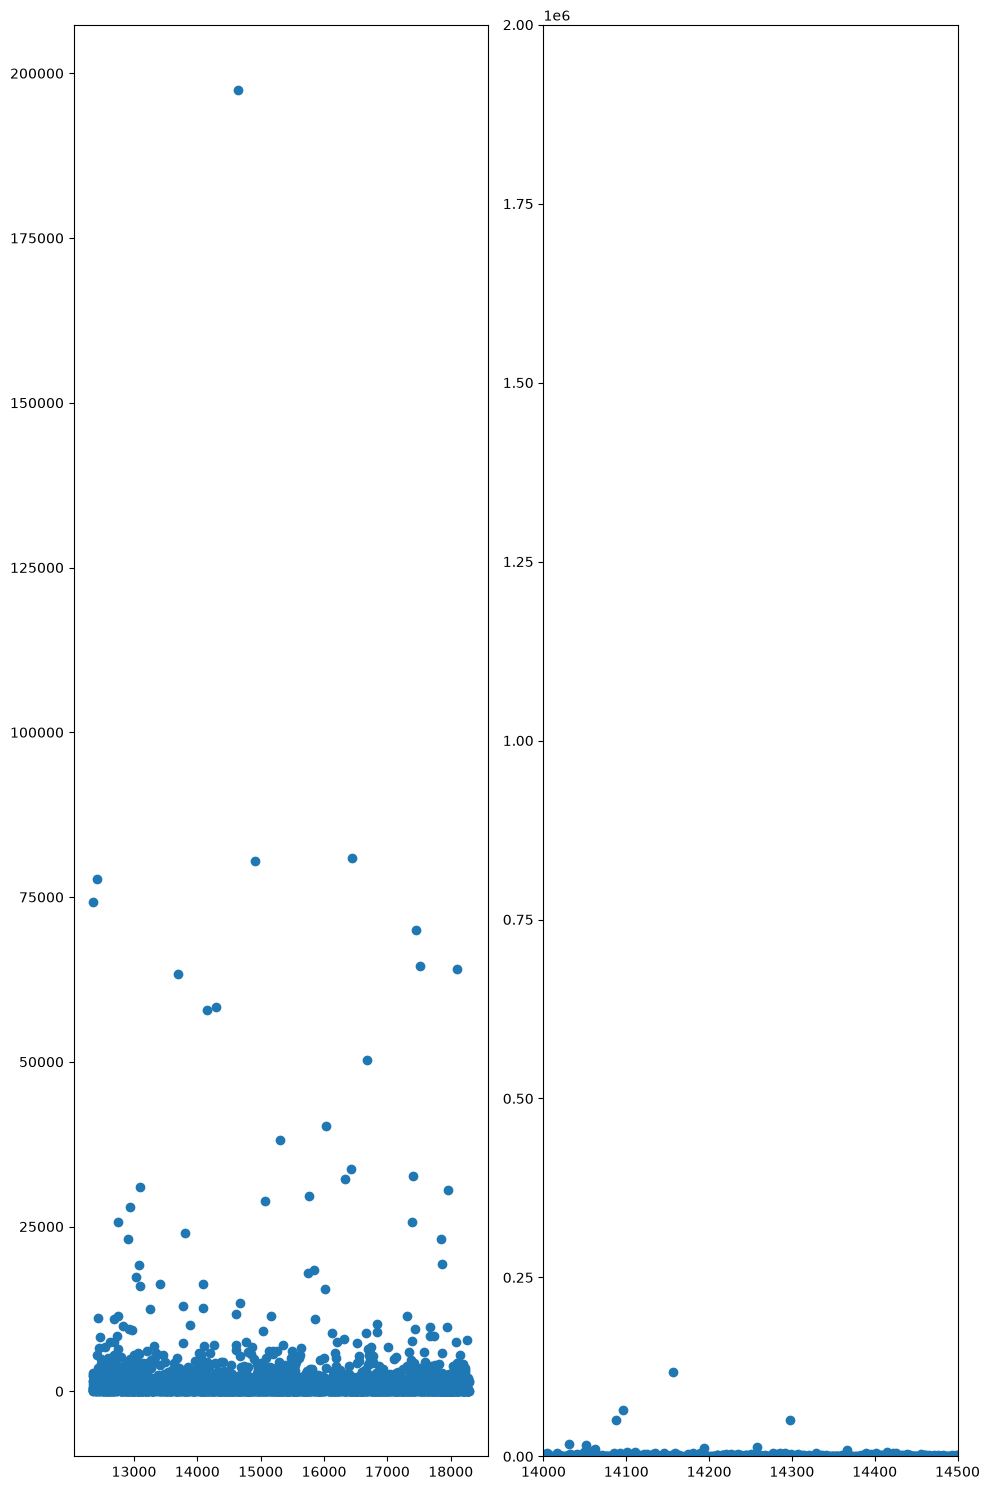

In [20]:
%matplotlib inline
import matplotlib.pyplot as plt

fig,axes=plt.subplots(1,2,figsize=(10,15))

# plt.scatter(x=plottable.index,y=plottable.Quantity)
axes[0].scatter(x=plottable.index,y=plottable.Quantity)

axes[1].scatter(x=plottable.index,y=plottable.Revenue)


##Zoom in
plt.xlim(14000,14500)
plt.ylim(0,2000000)


plt.tight_layout()
plt.show()



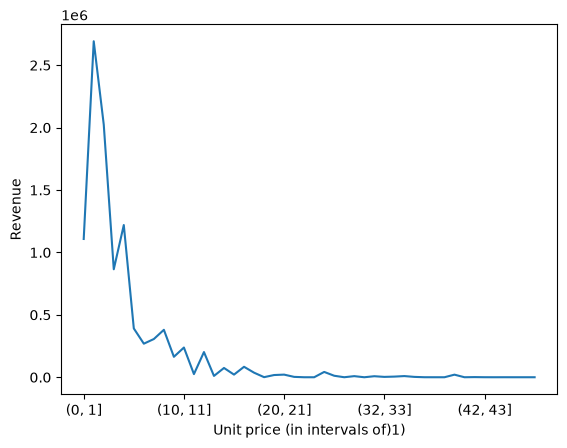

In [21]:
###Solution
revenue_per_price.plot()
plt.xlabel('Unit price (in intervals of)'+str(price_interval)+')')
plt.ylabel('Revenue')
plt.show()

#### 8.4 Make it look nicer.
x-axis needs values.  
y-axis isn't that easy to read; show in terms of millions.

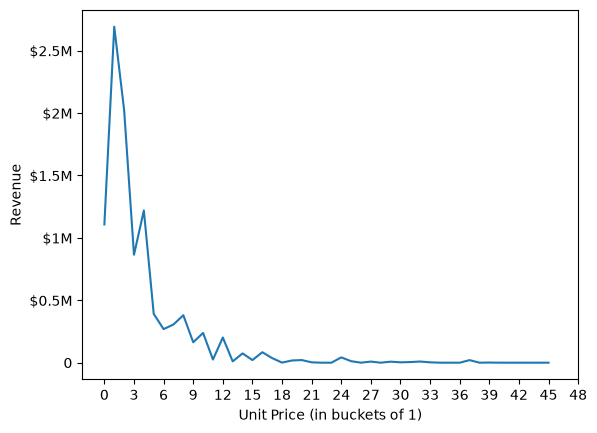

In [22]:
revenue_per_price.plot()

#Place labels
plt.xlabel('Unit Price (in buckets of '+str(price_interval)+')')
plt.ylabel('Revenue')

#Even though the data is bucketed in intervals of 1,
#I'll plot a little bit further apart from each other to avoid cluttering.
plt.xticks(
    np.arange(price_start,price_end,3),
    np.arange(price_start,price_end,3)
)
plt.yticks(
    [0,500000,1000000,1500000,2000000,2500000],
    ['0','$0.5M','$1M','$1.5M','$2M','$2.5M']
)
plt.show()

#Looks like a major chunk of our revenue comes from items worth $0-$3!


### BONUS: Create your own question and answer it.